# Comparação de Somadores Quânticos
Análise de recursos (Profundidade vs. Qubits) entre RCA, QFTDraper, AQFTDraper e QCLA.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit.circuit.quantumcircuit import QuantumCircuit
from qiskit.circuit import Gate
from qiskit.circuit.library import CXGate, CCXGate

class Carry(Gate):
    def __init__(self):
        super().__init__(name="Carry", num_qubits=4, params=[])
        qc = QuantumCircuit(4, name=self.name)
        c_in, a, b, c_out = 0, 1, 2, 3
        qc.append(CCXGate(), [a, b, c_out])
        qc.append(CXGate(),  [a, b])
        qc.append(CCXGate(), [c_in, b, c_out])
        self.definition = qc

class Sum(Gate):
    def __init__(self):
        super().__init__(name="Sum", num_qubits=3, params=[])
        qc = QuantumCircuit(3, name=self.name)
        c_in, a, b = 0, 1, 2
        qc.cx(a, b)
        qc.cx(c_in, b)
        self.definition = qc

class RippleCarryAdder(Gate):
    def __init__(self, n: int):
        num_q = 3 * n + 1
        super().__init__(name="RCA", num_qubits=num_q, params=[])
        carry = Carry(); sum_gate = Sum(); i_carry = carry.inverse()
        qc = QuantumCircuit(num_q, name=self.name)
        for i in range(0, num_q - 3, 3): qc.append(carry, [i, i + 1, i + 2, i + 3])
        qc.cx(num_q - 3, num_q - 2)
        qc.append(sum_gate, [num_q - 4, num_q - 3, num_q - 2])
        for j in range(num_q - 4, 0, -3):
            qc.append(i_carry,  [j - 3, j - 2, j - 1, j])
            qc.append(sum_gate, [j - 3, j - 2, j - 1])
        self.definition = qc

class QFT(Gate):
    def __init__(self, n: int, do_swaps: bool = True):
        self.do_swaps = do_swaps
        super().__init__(name="QFT", num_qubits=n, params=[])
        qc = QuantumCircuit(n, name=self.name)
        for j in range(n - 1, -1, -1):
            qc.h(j)
            for k in range(j - 1, -1, -1):
                lam = np.pi / (2.0 ** (j - k))
                qc.cp(lam, k, j)
        if self.do_swaps:
            for i in range(n // 2): qc.swap(i, n - i - 1)
        self.definition = qc

class AQFT(Gate):
    def __init__(self, n: int, do_swap: bool = True):
        self.do_swap = do_swap
        super().__init__(name="AQFT", num_qubits=n, params=[])
        qc = QuantumCircuit(n, name=self.name)
        m = int(np.ceil(np.log2(n))) if n > 0 else 0
        for j in range(n - 1, -1, -1):
            qc.h(j)
            for k in range(j - 1, max(j - m, -1), -1):
                lam = np.pi / (2.0 ** (j - k))
                qc.cp(lam, k, j)
        if self.do_swap:
            for i in range(n // 2): qc.swap(i, n - i - 1)
        self.definition = qc

class QFTDraperAdder(Gate):
    def __init__(self, n: int):
        num_q = 2 * n + 1
        super().__init__(name="QFTDraper", num_qubits=num_q, params=[])
        qc = QuantumCircuit(num_q, name=self.name)
        qr_a = list(range(n))
        qr_b = list(range(n, 2 * n + 1))
        
        qc.append(QFT(n + 1, do_swaps=False), qr_b)
        
        for j in range(n):
            for k in range(n - j + 1):
                lam = np.pi / (2 ** k)
                qc.cp(lam, qr_a[j], qr_b[j + k])
                
        qc.append(QFT(n + 1, do_swaps=False).inverse(), qr_b)
        self.definition = qc

class AQFTDraperAdder(Gate):
    def __init__(self, n: int):
        num_q = 2 * n + 1
        super().__init__(name="AQFTDraper", num_qubits=num_q, params=[])
        
        qc = QuantumCircuit(num_q, name=self.name)
        reg_a = list(range(n))
        reg_b = list(range(n, 2 * n + 1))
        
        qc.append(AQFT(n + 1, do_swap=False), reg_b)
        
        m = int(np.ceil(np.log2(n + 1))) if n > 0 else 0
        for k in range(m + 1):
            lam = np.pi / (2 ** k)
            for j in range(min(n, n - k + 1)):
                qc.cp(lam, reg_a[j], reg_b[j + k])
                
        qc.append(AQFT(n + 1, do_swap=False).inverse(), reg_b)
        
        self.definition = qc

def _ptree(n):
    idx, k = {}, 0
    logn = int(np.floor(np.log2(n))) if n >= 1 else 0
    for t in range(1, logn + 1):
        for m in range(1, n // (2 ** t)):
            idx[(t, m)] = k; k += 1
    return idx, k, logn

def _carry_ccx(n, cmap, pmap, ancmap):
    Pidx, _, logn = _ptree(n)
    P = lambda t, m: pmap[m] if t == 0 else ancmap[(t, m)]
    g = []
    for t in range(1, logn + 1):
        for m in range(1, n // (2 ** t)): g.append((P(t - 1, 2 * m), P(t - 1, 2 * m + 1), P(t, m)))
    for t in range(1, logn + 1):
        for m in range(0, n // (2 ** t)):
            g.append((P(t - 1, 2 * m + 1), cmap[2 ** t * m + 2 ** (t - 1) - 1], cmap[2 ** t * m + 2 ** t - 1]))
    if n >= 2:
        for t in range(int(np.floor(np.log2((2 * n) / 3.0))), 0, -1):
            for m in range(1, (n - 2 ** (t - 1)) // (2 ** t) + 1):
                g.append((P(t - 1, 2 * m), cmap[2 ** t * m - 1], cmap[2 ** t * m + 2 ** (t - 1) - 1]))
    for t in range(logn, 0, -1):
        for m in range(1, n // (2 ** t)): g.append((P(t - 1, 2 * m), P(t - 1, 2 * m + 1), P(t, m)))
    return g

class CarryLookaheadAdder(Gate):
    def __init__(self, n: int):
        Pidx, pk, logn = _ptree(n)
        num_q = 4 * n + 1 + pk
        super().__init__(name="QCLA", num_qubits=num_q, params=[])
        qc = QuantumCircuit(num_q, name=self.name)
        a = list(range(n))
        b = list(range(n, 2 * n))
        s = list(range(2 * n, 3 * n + 1))
        c = list(range(3 * n + 1, 4 * n + 1))
        panc = list(range(4 * n + 1, 4 * n + 1 + pk))
        ancmap = {k: panc[v] for k, v in Pidx.items()} if pk > 0 else {}
        cg = _carry_ccx(n, c, b, ancmap)
        for i in range(n): qc.ccx(a[i], b[i], c[i])
        for i in range(n): qc.cx(a[i], b[i])
        for x1, x2, tg in cg: qc.ccx(x1, x2, tg)
        for i in range(n):
            qc.cx(b[i], s[i])
            if i >= 1: qc.cx(c[i - 1], s[i])
        qc.cx(c[n - 1], s[n])
        for x1, x2, tg in reversed(cg): qc.ccx(x1, x2, tg)
        for i in range(n): qc.cx(a[i], b[i])
        for i in range(n): qc.ccx(a[i], b[i], c[i])
        self.definition = qc


Calculando recursos para n=4...
Calculando recursos para n=8...
Calculando recursos para n=16...
Calculando recursos para n=32...


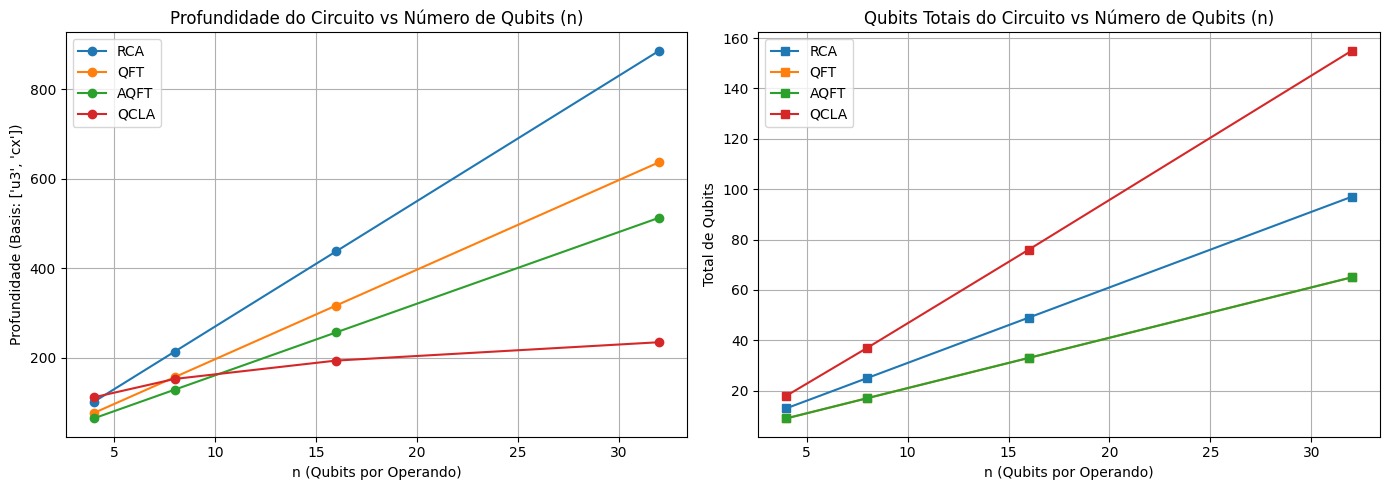

In [17]:
basis = ['u3', 'cx']
ns = [4, 8, 16, 32]

results = {
    'RCA': {'depth': [], 'qubits': []},
    'QFT': {'depth': [], 'qubits': []},
    'AQFT': {'depth': [], 'qubits': []},
    'QCLA': {'depth': [], 'qubits': []}
}

for n in ns:
    print(f"Calculando recursos para n={n}...")
    adders = {
        'RCA': RippleCarryAdder(n),
        'QFT': QFTDraperAdder(n),
        'AQFT': AQFTDraperAdder(n),
        'QCLA': CarryLookaheadAdder(n)
    }
    
    for name, gate in adders.items():
        qc = QuantumCircuit(gate.num_qubits)
        qc.append(gate, range(gate.num_qubits))
        
        qc_transpiled = transpile(qc, basis_gates=basis, optimization_level=1)
        
        results[name]['depth'].append(qc_transpiled.depth())
        results[name]['qubits'].append(gate.num_qubits)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in results:
    ax1.plot(ns, results[name]['depth'], marker='o', label=name)
    ax2.plot(ns, results[name]['qubits'], marker='s', label=name)

ax1.set_title('Profundidade do Circuito vs Número de Qubits (n)')
ax1.set_xlabel('n (Qubits por Operando)')
ax1.set_ylabel(f'Profundidade (Basis: {basis})')
ax1.legend()
ax1.grid(True)

ax2.set_title('Qubits Totais do Circuito vs Número de Qubits (n)')
ax2.set_xlabel('n (Qubits por Operando)')
ax2.set_ylabel('Total de Qubits')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Calculando recursos para n=16...
Calculando recursos para n=32...
Calculando recursos para n=64...
Calculando recursos para n=128...
Calculando recursos para n=256...
Calculando recursos para n=512...


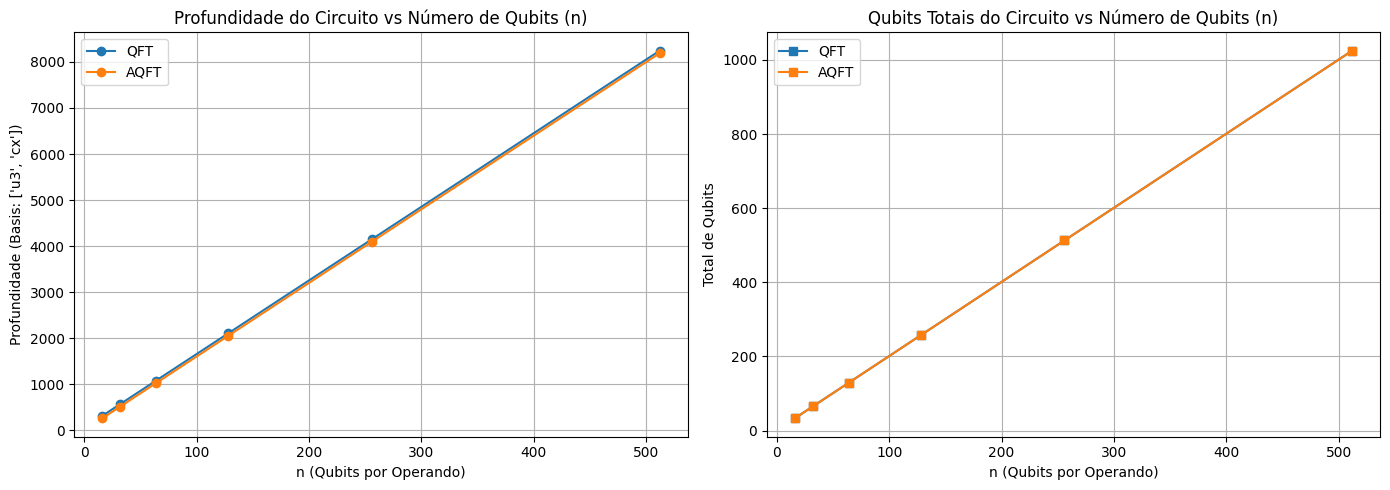

In [19]:
ns_asymptotic = [16, 32, 64, 128, 256, 512]


results_asymptotic = {
    'QFT': {'depth': [], 'qubits': []},
    'AQFT': {'depth': [], 'qubits': []}
}

for n in ns_asymptotic:
    print(f"Calculando recursos para n={n}...")
    adders = {
        'QFT': QFTDraperAdder(n),
        'AQFT': AQFTDraperAdder(n)
    }
    
    for name, gate in adders.items():
            qc = QuantumCircuit(gate.num_qubits)
            qc.append(gate, range(gate.num_qubits))
            
            qc_transpiled = transpile(qc, basis_gates=basis, optimization_level=2)
            
            results_asymptotic[name]['depth'].append(qc_transpiled.depth())
            results_asymptotic[name]['qubits'].append(gate.num_qubits)
            
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in results_asymptotic:
    ax1.plot(ns_asymptotic, results_asymptotic[name]['depth'], marker='o', label=name)
    ax2.plot(ns_asymptotic, results_asymptotic[name]['qubits'], marker='s', label=name)

ax1.set_title('Profundidade do Circuito vs Número de Qubits (n)')
ax1.set_xlabel('n (Qubits por Operando)')
ax1.set_ylabel(f'Profundidade (Basis: {basis})')
ax1.legend()
ax1.grid(True)

ax2.set_title('Qubits Totais do Circuito vs Número de Qubits (n)')
ax2.set_xlabel('n (Qubits por Operando)')
ax2.set_ylabel('Total de Qubits')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [20]:
print(results_asymptotic["AQFT"])
print(results_asymptotic["QFT"])

{'depth': [255, 511, 1023, 2047, 4095, 8191], 'qubits': [33, 65, 129, 257, 513, 1025]}
{'depth': [309, 565, 1077, 2101, 4149, 8245], 'qubits': [33, 65, 129, 257, 513, 1025]}
